##  Course Details

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSC 821 - Design and Analysis of Algorithms
##### **Module:** Module 9 - Advanced Topics in Algorithms
##### **Assignment:** To implement the Fast Fourier Transform (FFT) and various Pattern Matching Algorithms


### Group Details - Group 6 - MSAI

**1. Marrion Kiprop Cherop** — ST62/80971/2024

**2. Kulet Eliud Muchangi** — ST62/56968/2025
  
**3. Michael Musya** — ST62/56377/2025

**4. Mark Makau** — ST62/55795/2025
  
**5. John Obunga Edward** — ST62/55731/2025

**6. Peter Kemari Onyiego** - ST62/55886/2025




### 1. Fast Fourier Transform (FFT)

The Discrete Fourier Transform (DFT) converts a discrete signal from the time domain into the frequency domain by expressing it as a sum of complex sinusoids. A direct implementation of the DFT takes (O(N^2)) time for (N) samples.

The Fast Fourier Transform (FFT), specifically the Cooley–Tukey algorithm, reduces this cost to (O(NlogN)) by using a divide-and-conquer strategy. It recursively splits the input into even-indexed and odd-indexed samples, computes their transforms, and then combines them using complex exponential “twiddle factors”.


### 1.1. FFT Code Implementation

In [12]:
import math
import cmath
from typing import List

import numpy as np
import matplotlib.pyplot as plt


def fft_recursive(x: List[complex]) -> List[complex]:
    """
    Recursive Cooley–Tukey FFT implementation.

    Args:
        x: list of complex samples (length N, preferably a power of 2).

    Returns:
        List of complex frequency coefficients of length N.
    """
    N = len(x)
    if N == 1:
        return x

    if N % 2 != 0:
        raise ValueError("Length of input must be a power of 2 for this simple FFT.")

    # Split into even and odd parts
    even = fft_recursive(x[0::2])
    odd = fft_recursive(x[1::2])

    # Combine step
    result = [0] * N
    for k in range(N // 2):
        twiddle = cmath.exp(-2j * math.pi * k / N) * odd[k]
        result[k] = even[k] + twiddle
        result[k + N // 2] = even[k] - twiddle

    return result


### 1.3.FFT Test

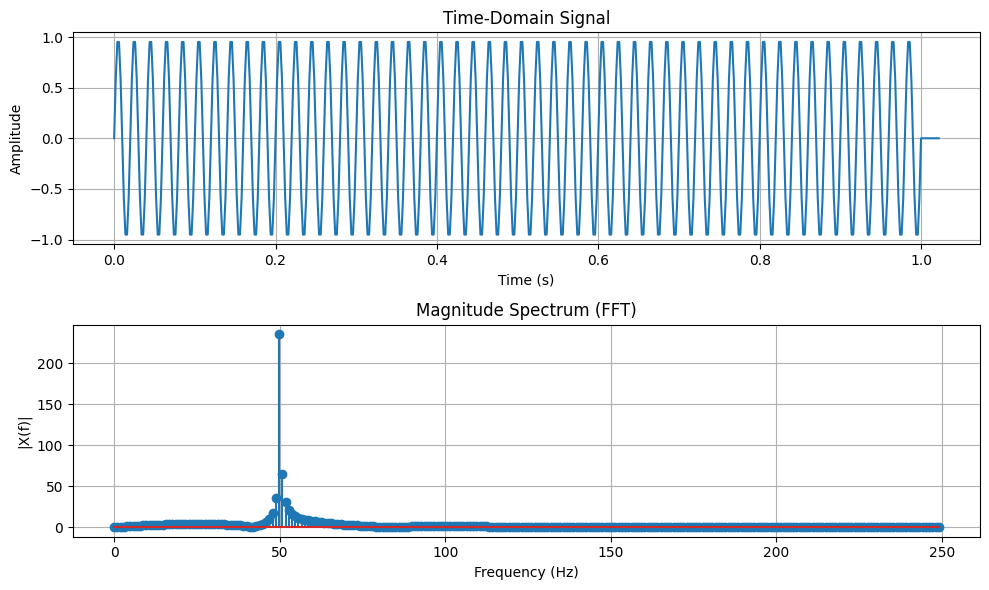

In [13]:
# --- Parameters for test signal ---
fs = 500      # Sampling frequency (Hz)
T = 1.0       # Duration (s)
f0 = 50       # Test sine frequency (Hz)

t = np.linspace(0, T, int(fs * T), endpoint=False)
signal = np.sin(2 * math.pi * f0 * t)

# Ensure length is a power of 2 (zero-pad if needed)
N = len(signal)
N_pow2 = 1
while N_pow2 < N:
    N_pow2 *= 2

if N_pow2 != N:
    padded_signal = np.zeros(N_pow2)
    padded_signal[:N] = signal
    signal = padded_signal
    N = N_pow2

# Prepare data for FFT
x = [complex(s, 0.0) for s in signal]


X = fft_recursive(x)

# Frequency axis and magnitude spectrum
freqs = np.fft.fftfreq(N, d=1.0 / fs)
magnitude = np.abs(X)

# --- Plot time signal and magnitude spectrum ---
plt.figure(figsize=(10, 6))

# Time-domain signal
plt.subplot(2, 1, 1)
plt.plot(np.arange(N) / fs, signal)
plt.title("Time-Domain Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Frequency-domain (magnitude, positive freqs)
plt.subplot(2, 1, 2)
half = N // 2
plt.stem(freqs[:half], magnitude[:half])
plt.title("Magnitude Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)|")
plt.grid(True)

plt.tight_layout()
plt.show()

The implemented function `fft_recursive` uses the Cooley–Tukey FFT algorithm:

- It recursively splits the input sequence into **even** and **odd** indices.
- It computes the FFT of each half.
- It combines the two halves using complex twiddle factors 
- The recursion depth is (log_2 N), and at each level we process (N) elements, giving an overall time complexity of (O(N log N)).

In the test, a sampled sine wave is transformed into the frequency domain. The FFT output is then converted to a magnitude spectrum and plotted against frequency, showing how the signal’s energy is distributed across frequencies.


## 2. Pattern Matching
## 2.1 Naive Pattern Matching

The naive (brute-force) pattern matching algorithm checks for the pattern at every possible alignment in the text. For each starting index (i) in the text, it compares the pattern characters one by one with the corresponding text characters.

In the worst case, this leads to (O((n - m + 1) c * m)) time, which is (O(nm)), where:
- (n) = length of the text
- (m) = length of the pattern

## 2.2 Naive Matching Code

In [14]:
from typing import List


def naive_match(text: str, pattern: str) -> List[int]:
    """
    Naive string matching algorithm.

    Args:
        text: The full text to search in.
        pattern: The pattern to look for.

    Returns:
        A list of starting indices where the pattern occurs in the text.
    """
    n, m = len(text), len(pattern)
    if m == 0 or m > n:
        return []

    matches: List[int] = []
    # Try matching pattern at every possible position i
    for i in range(n - m + 1):
        j = 0
        # Check character by character
        while j < m and text[i + j] == pattern[j]:
            j += 1
        if j == m:
            matches.append(i)

    return matches


### 2.3 Naive PM Test

In [15]:
# Example text and pattern for testing
text = "abcababcabdababcab"
pattern = "abcab"


indices = naive_match(text, pattern)

print("Naive matches at indices:", indices)
print(f"Total matches found: {len(indices)}")



Naive matches at indices: [0, 5, 13]
Total matches found: 3


The function `naive_match(text, pattern)`:

- Iterates over all possible starting positions `i` from `0` to `n - m`.
- For each `i`, it compares `pattern[0..m-1]` with `text[i..i+m-1]` character by character.
- If all `m` characters match, index `i` is recorded as a valid match.

**Time complexity:**

- Outer loop runs up to \(n - m + 1\) times.
- Inner loop (character comparisons) can take up to \(m\) steps per position.
- Worst-case time complexity is \(O(nm)\).

The naive algorithm is simple and easy to implement, but becomes inefficient for very long texts or patterns. It is mainly suitable when \(n\) and \(m\) are relatively small or performance is not critical.


### 2.5 KMP (Knuth–Morris–Pratt) Algorithm

The Knuth–Morris–Pratt (KMP) algorithm improves on the naive approach by avoiding re-checking characters. It precomputes a failure function called the **LPS (Longest Prefix-Suffix)** array for the pattern.

- `LPS[i]` = length of the longest proper prefix of `pattern[0..i]` that is also a suffix of `pattern[0..i]`.

During matching, when a mismatch occurs at pattern index `j`, KMP does not restart from the beginning of the pattern. Instead, it uses:

[
j = {LPS}[j - 1]
]

to shift the pattern so that the longest possible prefix is reused. This ensures that each character in the text is processed at most a constant number of times.

### 2.6 KMP Code

In [16]:
from typing import List


def build_lps(pattern: str) -> List[int]:
    """
    Build the LPS (Longest Prefix which is also Suffix) array for KMP.

    LPS[i] = length of the longest proper prefix of pattern[0..i]
             which is also a suffix of pattern[0..i].
    """
    m = len(pattern)
    lps = [0] * m
    length = 0  # length of previous longest prefix-suffix
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_match(text: str, pattern: str) -> List[int]:
    """
    KMP string matching algorithm.

    Args:
        text: The full text to search in.
        pattern: The pattern to look for.

    Returns:
        A list of starting indices where the pattern occurs.
    """
    n, m = len(text), len(pattern)
    if m == 0 or m > n:
        return []

    lps = build_lps(pattern)
    matches: List[int] = []

    i = 0  # index in text
    j = 0  # index in pattern

    while i < n:
        if text[i] == pattern[j]:
            i += 1
            j += 1
            if j == m:
                # full match ends at i - 1, so start index is i - j
                matches.append(i - j)
                # continue searching for next match
                j = lps[j - 1]
        else:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches


## 2.7 KMP Testing

In [17]:
# Example text and pattern for KMP
text = "abcababcabdababcab"
pattern = "abcab"
kmp_indices = kmp_match(text, pattern)

print("KMP matches at indices:", kmp_indices)
print(f"Total matches found: {len(kmp_indices)}")

KMP matches at indices: [0, 5, 13]
Total matches found: 3


The KMP implementation has two phases:

1. **Preprocessing (build LPS):**
   - The function `build_lps(pattern)` computes the LPS array in \(O(m)\) time.
   - It tracks the current longest prefix-suffix length `length`.
   - On a mismatch while building, it falls back to `lps[length - 1]` instead of resetting to zero.

2. **Search:**
   - The function `kmp_match(text, pattern)` scans the text and pattern simultaneously.
   - On a match, both `i` (text index) and `j` (pattern index) are advanced.
   - On a mismatch:
     - If `j > 0`, the pattern index is updated using `j = lps[j - 1]`.
     - If `j == 0`, the text index `i` is incremented.
   - When `j == m`, a full match is found at `i - j`, and `j` is reset using LPS to continue the search.

**Time complexity:**
- LPS construction: \(O(m)\)
- Search phase: \(O(n)\)
- Overall: \(O(n + m)\) in the worst case.

KMP is preferred when we need guaranteed linear-time matching, especially when the same pattern is searched repeatedly over large texts.


### 2.9 Boyer–Moore Algorithm (Bad Character Heuristic)

The Boyer–Moore algorithm compares the pattern to the text from **right to left** and uses heuristic rules to skip ahead when a mismatch occurs. Here we implement only the **bad character heuristic**:

- For each character in the pattern, we store its **last occurrence index**.
- On a mismatch at pattern index `j` with text character `c`, the shift is:
  [
  shift = max(1, j - lastOcc(c))
  ]
- If `c` does not appear in the pattern, `lastOcc(c) = -1`, and the pattern can be shifted past `j`.

This often allows the algorithm to skip multiple characters of the text, making it fast in practice, especially on large alphabets and random text.


### 3.0 Boyer-Moore Code 

In [18]:
from typing import List, Dict


def build_bad_char_table(pattern: str) -> Dict[str, int]:
    """
    Build the bad character table for Boyer–Moore.
    For each character in the pattern, store its last index.
    """
    table: Dict[str, int] = {}
    for i, ch in enumerate(pattern):
        table[ch] = i
    return table


def boyer_moore_bad_character(text: str, pattern: str) -> List[int]:
    """
    Boyer–Moore string matching using the bad character heuristic only.

    Args:
        text: The full text to search in.
        pattern: The pattern to look for.

    Returns:
        A list of starting indices where the pattern occurs.
    """
    n, m = len(text), len(pattern)
    if m == 0 or m > n:
        return []

    bad_char = build_bad_char_table(pattern)
    matches: List[int] = []

    s = 0  # current shift of the pattern over the text
    while s <= n - m:
        j = m - 1

        # move from right to left in the pattern
        while j >= 0 and pattern[j] == text[s + j]:
            j -= 1

        if j < 0:
            # full match found at shift s
            matches.append(s)
            # shift pattern to look for next possible match
            next_index = s + m
            if next_index < n:
                c = text[next_index]
                last_pos = bad_char.get(c, -1)
                s += m - last_pos - 1
            else:
                s += 1
        else:
            # mismatch at index j -> apply bad character rule
            c = text[s + j]
            last_pos = bad_char.get(c, -1)
            shift = max(1, j - last_pos)
            s += shift

    return matches


### 3.1 Boyer-Moore Test

In [19]:
# Example text and pattern for Boyer–Moore (bad character)
text = "abcababcabdababcab" 
pattern = "abcab"


bm_indices = boyer_moore_bad_character(text, pattern)

print("Boyer–Moore (bad character) matches at indices:", bm_indices)
print(f"Total matches found: {len(bm_indices)}")



Boyer–Moore (bad character) matches at indices: [0, 5, 13]
Total matches found: 3


The Boyer–Moore implementation uses a bad character table:

- `build_bad_char_table(pattern)` records the last index of each character in the pattern.
- During the search, the pattern is aligned at shift `s` over the text.
- Characters are compared from **right to left**:
  - If all characters match, a full match is recorded at shift `s`.
  - If a mismatch occurs at pattern index `j`:
    - Let `c` be the mismatching text character at position `s + j`.
    - Let `last_pos` be the last occurrence of `c` in the pattern (or -1 if not present).
    - The shift is computed as:
      [
      text{shift} = max(1, j - last_pos)
      ]
    - This often moves the pattern forward by multiple positions, skipping text characters that cannot match.

**Time complexity:**

- Preprocessing (bad character table): \(O(m)\).
- Search:
  - Worst case: \(O(nm)\).
  - Average case: typically much faster, often sublinear in \(n\), because the pattern jumps ahead by more than one position on many mismatches.

In practice, Boyer–Moore is usually implemented with both the **bad character** and **good suffix** heuristics, which together make it one of the most efficient algorithms for text search in editors, compilers, and search tools.


### 3.3 Boyer–Moore – Good Suffix Heuristic

The **good suffix** heuristic is used when a suffix of the pattern has matched the text, but a mismatch occurs before that suffix.

Suppose we matched `pattern[j+1..m-1]` (a “good suffix”) and then mismatched at `j`. The good suffix rule shifts the pattern so that:

1. Either another occurrence of this suffix appears **earlier** in the pattern and can be aligned with the text, or
2. A **suffix of this suffix** matches a **prefix** of the pattern (prefix–suffix overlap), or
3. If neither is possible, the pattern is shifted past the suffix.

We capture this in a **good suffix table** `gs[j]`, which gives the shift to apply when a mismatch occurs at index `j`.

### 3.4 Boyer-Moore - GS Table

In [20]:
from typing import List, Dict

def build_bad_char_table(pattern: str) -> Dict[str, int]:
    table: Dict[str, int] = {}
    for i, ch in enumerate(pattern):
        table[ch] = i
    return table

def build_good_suffix_tables(pattern: str):
    """
    Build suffix[] and prefix[] for the good suffix rule.

    suffix[k] = start index of a substring in pattern that matches the
                suffix of length k at the end of pattern, or -1 if none.
    prefix[k] = True if a prefix of pattern of length k is also a suffix.
    """
    m = len(pattern)
    suffix = [-1] * m
    prefix = [False] * m

    for i in range(m - 1):  # pattern[0..i]
        j = i
        k = 0  # length of matched suffix
        # match from the end of pattern backwards
        while j >= 0 and pattern[j] == pattern[m - 1 - k]:
            j -= 1
            k += 1
            suffix[k] = j + 1  # starting index of this suffix

        if j == -1:
            # matched all the way to the beginning -> prefix
            prefix[k] = True

    return suffix, prefix

def move_by_good_suffix(j: int, m: int, suffix: List[int], prefix: List[bool]) -> int:
    """
    Compute how far to shift using good suffix when mismatch at index j.
    """
    k = m - 1 - j  # length of matched suffix
    if k <= 0:
        return 0

    # Case 1: A substring of pattern matches this suffix
    if suffix[k] != -1:
        return j + 1 - suffix[k]

    # Case 2: Some prefix of pattern matches suffix of pattern
    for r in range(k - 1, 0, -1):
        if prefix[r]:
            return m - r

    # Case 3: No match -> move full length
    return m


### 3.4. Boyer–Moore with Bad Character + Good Suffix Code

In [21]:
def boyer_moore_full(text: str, pattern: str) -> List[int]:
    n, m = len(text), len(pattern)
    if m == 0 or m > n:
        return []

    bad_char = build_bad_char_table(pattern)
    suffix, prefix = build_good_suffix_tables(pattern)

    matches: List[int] = []
    s = 0  # current shift

    while s <= n - m:
        j = m - 1

        # Compare from right to left
        while j >= 0 and pattern[j] == text[s + j]:
            j -= 1

        if j < 0:
            # Full match
            matches.append(s)

            # Shift after match: use good-suffix for length 1 if possible, else 1
            gs_shift = 1
            if m > 1 and suffix[1] != -1:
                gs_shift = m - 1 - suffix[1]
            s += max(gs_shift, 1)
        else:
            # Mismatch
            c = text[s + j]
            last_pos = bad_char.get(c, -1)
            bad_shift = j - last_pos
            if bad_shift < 1:
                bad_shift = 1

            gs_shift = move_by_good_suffix(j, m, suffix, prefix)

            s += max(bad_shift, gs_shift, 1)

    return matches


### 3.5 Boyer-Moore Full Test

In [22]:
# Example text and pattern for Boyer–Moore full (BC + GS)
text = "abcababcabdababcab"
pattern = "abcab"

bm_full_indices = boyer_moore_full(text, pattern)

print("Boyer–Moore (BC + GS) matches at indices ):", bm_full_indices)
print(f"Total matches found: {len(bm_full_indices)}")

Boyer–Moore (BC + GS) matches at indices ): [0, 5, 13]
Total matches found: 3


The full Boyer–Moore implementation combines:

1. **Bad Character Heuristic**
   - Uses `build_bad_char_table(pattern)` to store the last index of each character in the pattern.
   - On a mismatch at index `j` with text character `c`, it proposes a shift:
     `[
     BC shift = max(1, j - lastOcc(c))
     ]`

2. **Good Suffix Heuristic**
   - Uses `build_good_suffix_table(pattern)` to compute `gs[j]`, the shift when `pattern[j+1..m-1]` has matched.
   - The table encodes:
     - Internal occurrences of the matched suffix (case 1).
     - Prefix–suffix overlaps (case 2).
   - On a mismatch at index `j`, it proposes a shift:
     [{GS shift} = gs[j]]

3. **Combined Shift**
   - For each mismatch, the algorithm takes:
     [{shift} = max({BC shift}, {GS shift})]
   - This usually gives a larger jump than either heuristic alone.

**Time complexity:**

- Preprocessing:
  - Bad character table: \(O(m)\)
  - Good suffix table: \(O(m^2)\) in this simple version (more optimized variants exist).
- Search:
  - Worst case: \(O(nm)\)
  - Average case: typically very fast and often sublinear in \(n\), especially on large alphabets.

Using both heuristics, Boyer–Moore is one of the most efficient practical algorithms for pattern matching in real-world text processing (e.g., editors, search engines, compilers).
